# Quantitative Analysis of the German Power Markets
### Day-ahead–intraday spreads: market structure, forecasting and execution controls

This notebook analyses the difference between German day-ahead prices and the later intraday reference index, ID-AEP. It explores historical patterns and tests whether forecasting models improve on simple benchmarks.

The dataset covers **1 September 2024–31 August 2026**, using DE-LU day-ahead prices and published ID-AEP values at 15-minute delivery resolution. Models are evaluated across twelve monthly test windows using data excluded from training.

### What this analysis covers

- How spread patterns changed after the introduction of 15-minute day-ahead prices.

- How wind, solar and demand forecast errors relate to spreads.

- Whether forecasting models outperform a zero-spread benchmark.

- How forecast accuracy and uncertainty vary across months and extreme-price events.

The analysis uses real historical market data. ID-AEP is calculated from trades rather than an executable quote, so its difference from day-ahead prices is treated as a spread, not as trading profit.

In [5]:
## Environment Setup and Functions

import os
os.environ.setdefault("OMP_NUM_THREADS", "2")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "2")
from pathlib import Path
from dataclasses import dataclass
from datetime import datetime, timezone
from urllib.request import Request, urlopen
from urllib.parse import quote
import io, json, re, base64, gzip, hashlib, time, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
from IPython.display import display, Markdown, HTML
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from scipy.optimize import milp, Bounds, LinearConstraint
from scipy.sparse import lil_matrix
import sklearn, scipy, matplotlib

ROOT = Path.cwd()
DATA = ROOT / "data"; REPORTS = ROOT / "reports"
DATA.mkdir(exist_ok=True); REPORTS.mkdir(exist_ok=True)
COLORS = {"navy":"#112B45", "teal":"#087E8B", "orange":"#D87932", "red":"#B34757", "grey":"#78909C"}
plt.rcParams.update({"figure.figsize":(11.5,4.8), "figure.dpi":120,
 "axes.spines.top":False,"axes.spines.right":False,"axes.titleweight":"bold",
 "axes.labelcolor":COLORS['navy'],"text.color":COLORS['navy'],"font.size":10,
 "axes.grid":True,"grid.alpha":.18,"figure.facecolor":"white","axes.facecolor":"white"})
pd.set_option("display.max_columns",15)
pd.set_option("display.float_format",lambda x:f"{x:,.2f}")

def save_chart(fig, name):
    fig.tight_layout()
    fig.savefig(REPORTS / (name+".png"),dpi=180,bbox_inches="tight")
    plt.show()

def read_utc_csv(path):
    d=pd.read_csv(path,index_col=0)
    d.index=pd.to_datetime(d.index,utc=True)
    d.index.name="delivery_start_utc"
    return d

print("Python",sys.version.split()[0],"| pandas",pd.__version__,"| sklearn",sklearn.__version__,"| scipy",scipy.__version__)

Python 3.14.6 | pandas 2.3.3 | sklearn 1.9.0 | scipy 1.18.0


## 1 · Data sources, units and reproducibility

| Series | Source and access | Unit | Use |
|---|---|---|---|
| DE-LU day-ahead price | Bundesnetzagentur / SMARD, via Energy-Charts API | EUR/MWh | Price analysis, forecast inputs and battery settlement |
| Wind, solar, load and thermal generation | Fraunhofer ISE Energy-Charts | MW | Market explanation; generation is not plant availability |
| Day-ahead wind, solar and load forecasts | Energy-Charts API | MW | Historical forecast-error analysis; full publication vintages are unavailable |
| Physical cross-border flows | Energy-Charts API | GW converted to MW | Positive values represent net imports, not available trading capacity |
| ID-AEP | Netztransparenz public CSV download | EUR/MWh | Later intraday reference index |

**Attribution:** Bundesnetzagentur | SMARD.de for day-ahead prices; energy-charts.info / Fraunhofer ISE for the other Energy-Charts series, under CC BY 4.0. Transformations include UTC normalisation, series selection, unit conversion, timestamp joins and repetition of hourly day-ahead prices across their four delivery quarters.

The embedded `SOURCE_MANIFEST` records provenance and checksums. ID-AEP download metadata are saved locally when the source is fetched. No open redistribution licence is assumed for the index's raw data.

The dataset records a change to 15-minute day-ahead delivery prices on **1 October 2025** [S3]. Earlier hourly prices are repeated, not interpolated. Missing core prices are not filled. UTC identifies delivery intervals; Europe/Berlin is used for calendar features, including daylight-saving transitions.


In [6]:
# Embedded CC-BY snapshot; collapsed by default in supported notebook frontends.
OPEN_DATA_B64 = """..."""
OPEN_DATA_SHA256 = "4c83e95946665827eba1a19d37da2102a1b58f7f78ecde98e856b39a74fbe19a"

In [7]:
blob=base64.b64decode(OPEN_DATA_B64)
assert hashlib.sha256(blob).hexdigest()==OPEN_DATA_SHA256, "Snapshot checksum mismatch"
open_data=pd.read_csv(io.BytesIO(blob),compression="gzip",index_col=0)
open_data.index=pd.to_datetime(open_data.index,utc=True)
open_data.index.name="delivery_start_utc"

ID_SOURCE="https://www.netztransparenz.de/de-de/Regelenergie/Ausgleichsenergiepreis/Index-Ausgleichsenergiepreis"
ID_CACHE=DATA/"id_aep_private_cache.csv.gz"

def get_public_bytes(url):
    # Three attempts with modest backoff; do not substitute artificial data.
    from urllib.error import HTTPError
    for attempt in range(3):
        try:
            req=Request(url,headers={"User-Agent":"GermanPowerResearch/1.0 (public data research)"})
            with urlopen(req,timeout=55) as response: return response.read()
        except Exception as exc:
            if attempt==2:
                raise RuntimeError("Public source unavailable. Keep existing notebook outputs; retry later or use the publisher CSV download.") from exc
            delay=30 if isinstance(exc,HTTPError) and exc.code==429 else 3
            time.sleep(delay)

def load_id_aep():
    if ID_CACHE.exists(): return read_utc_csv(ID_CACHE)
    page=get_public_bytes(ID_SOURCE).decode()
    match=re.search(r'const downloadHandlerConfig = (\{.*?\});',page)
    if match is None: raise RuntimeError("Publisher download format changed; update adapter, do not infer prices.")
    config=json.loads(match.group(1))
    request={"LocalFrom":"2024-09-01","LocalTo":"2026-09-01","ResultTimeZone":"utc","Settings":config['Settings']}
    token=quote(base64.b64encode(json.dumps(request).encode()).decode())
    raw=get_public_bytes("https://www.netztransparenz.de"+config['CsvDownloadApiRoute']+"?request="+token)
    f=pd.read_csv(io.BytesIO(raw),sep=";",decimal=",",encoding="utf-8-sig")
    if len(f.columns)!=6 or "ID AEP" not in f.columns[-1]: raise ValueError("Unexpected ID-AEP CSV schema")
    if not f.iloc[:,2].eq("UTC").all(): raise ValueError("Expected UTC source timestamps")
    idx=pd.to_datetime(f.iloc[:,0]+" "+f.iloc[:,1],format="%d.%m.%Y %H:%M",utc=True)
    d=pd.DataFrame({"id_aep_eur_mwh":pd.to_numeric(f.iloc[:,-1],errors="coerce").values},index=idx)
    d.index.name="delivery_start_utc"
    if d.index.duplicated().any(): raise ValueError("Duplicate ID-AEP delivery intervals")
    d=d.reindex(open_data.index)
    d.to_csv(ID_CACHE,compression="gzip")
    metadata={"source":ID_SOURCE,"raw_sha256":hashlib.sha256(raw).hexdigest(),
              "retrieved_at_utc":datetime.now(timezone.utc).isoformat(),"raw_not_in_application_bundle":True}
    (DATA/"id_aep_local_fetch.json").write_text(json.dumps(metadata,indent=2))
    return d

market=open_data.join(load_id_aep())
assert market.index.is_unique and market.index.is_monotonic_increasing
assert (market.index.to_series().diff().dropna()==pd.Timedelta(minutes=15)).all()
assert len(market)==70080
quality=pd.DataFrame({"missing":market.isna().sum(),"min":market.min(),"max":market.max()})
# No missing core prices may silently disappear from the study.
assert market[['da_eur_mwh','id_aep_eur_mwh']].notna().all().all()
display(quality)
local=market.index.tz_convert("Europe/Berlin")
day_lengths=pd.Series(1,index=local).groupby(local.date).sum()
assert day_lengths.isin([92,96,100]).all()
print("Local day lengths:",day_lengths.value_counts().sort_index().to_dict())
print("1 MW × 0.25 h = 0.25 MWh; prices are EUR/MWh, power series are MW.")

,missing,min,max
da_eur_mwh,0,-499.99,936.28
lignite_mw,0,"1,352.40","13,687.20"
hard_coal_mw,0,121.10,"8,525.30"
gas_generation_mw,0,831.10,"17,719.40"
wind_offshore_mw,0,0.00,"8,486.40"
wind_onshore_mw,0,41.70,"47,300.00"
solar_mw,0,0.00,"58,507.00"
load_mw,0,"32,299.90","78,372.60"
net_import_mw,0,"-18,593.00","17,329.00"
forecast_solar_mw,0,0.00,"58,051.90"


Local day lengths: {92: 2, 96: 726, 100: 2}
1 MW × 0.25 h = 0.25 MWh; prices are EUR/MWh, power series are MW.


In [8]:
def add_market_features(data):
    """UTC joins, local calendar. Realised fundamentals are explanatory only."""
    d = data.copy()
    local = d.index.tz_convert("Europe/Berlin")
    d["local_day"] = local.date
    d["hour"] = local.hour
    d["quarter"] = local.minute // 15
    d["day_of_week"] = local.dayofweek
    d["month"] = local.month
    d["day_sin"] = np.sin(2 * np.pi * local.dayofyear / 365.25)
    d["day_cos"] = np.cos(2 * np.pi * local.dayofyear / 365.25)
    d["hour_sin"] = np.sin(2 * np.pi * (local.hour + local.minute / 60) / 24)
    d["hour_cos"] = np.cos(2 * np.pi * (local.hour + local.minute / 60) / 24)
    d["post_15m"] = (d["da_native_minutes"] == 15).astype(int)
    d["spread"] = d["id_aep_eur_mwh"] - d["da_eur_mwh"]
    d["wind_mw"] = d["wind_onshore_mw"] + d["wind_offshore_mw"]
    d["wind_forecast_mw"] = d["forecast_wind_onshore_mw"] + d["forecast_wind_offshore_mw"]
    d["residual_load_mw"] = d["load_mw"] - d["wind_mw"] - d["solar_mw"]
    d["residual_forecast_mw"] = d["forecast_load_mw"] - d["wind_forecast_mw"] - d["forecast_solar_mw"]
    d["residual_error_gw"] = (d["residual_load_mw"] - d["residual_forecast_mw"]) / 1000
    # Positive error = more residual demand than forecast. This is NOT known ex ante.
    day = d.groupby("local_day")["da_eur_mwh"]
    d["da_day_mean"] = day.transform("mean")
    d["da_day_range"] = day.transform("max") - day.transform("min")
    d["da_deviation"] = d["da_eur_mwh"] - d["da_day_mean"]
    d["da_ramp_back"] = d["da_eur_mwh"] - day.shift(4)
    d["da_ramp_forward"] = day.shift(-4) - d["da_eur_mwh"]
    # Grouping by delivery day avoids using tomorrow's unannounced DA auction.
    d["da_ramp_back"] = d["da_ramp_back"].fillna(0)
    d["da_ramp_forward"] = d["da_ramp_forward"].fillna(0)
    # Conservative DA forecasting lags: 48h remains safe over both DST transitions.
    d["da_lag_48h"] = d["da_eur_mwh"].shift(192)
    d["da_lag_168h"] = d["da_eur_mwh"].shift(672)
    d["lagged_day_mean"] = d["da_eur_mwh"].shift(192).rolling(96,min_periods=96).mean()
    return d


CALENDAR = ["hour", "quarter", "day_of_week", "month", "day_sin", "day_cos", "hour_sin", "hour_cos", "post_15m"]
ID_FEATURES = CALENDAR + ["da_eur_mwh", "da_day_mean", "da_day_range", "da_deviation", "da_ramp_back", "da_ramp_forward"]
DA_FEATURES = CALENDAR + ["da_lag_48h", "da_lag_168h", "lagged_day_mean"]

In [9]:
d=add_market_features(market)
# Ensure no realised fundamental slips into a model feature list.
for forbidden in ['id_aep_eur_mwh','spread','residual_error_gw','load_mw','solar_mw','net_import_mw']:
    assert forbidden not in ID_FEATURES+DA_FEATURES
summary=pd.DataFrame({
    'DA':d.da_eur_mwh.describe(percentiles=[.01,.05,.5,.95,.99]),
    'ID-AEP':d.id_aep_eur_mwh.describe(percentiles=[.01,.05,.5,.95,.99]),
    'ID-AEP minus DA':d.spread.describe(percentiles=[.01,.05,.5,.95,.99])})
display(summary)
print(f"Negative DA delivery hours: {(d.da_eur_mwh<0).sum()*.25:,.1f}")
print(f"Negative ID-AEP delivery hours: {(d.id_aep_eur_mwh<0).sum()*.25:,.1f}")
print("These are duration-weighted delivery hours, not counts of independent hourly auctions.")

,DA,ID-AEP,ID-AEP minus DA
count,"70,080.00","70,080.00","70,080.00"
mean,95.15,97.84,2.70
std,59.35,110.79,94.44
min,-499.99,"-4,340.20","-4,233.90"
1%,-18.03,-29.55,-100.99
5%,-0.06,-4.82,-60.15
50%,97.78,96.24,-2.12
95%,174.23,186.99,66.53
99%,260.14,322.83,172.65
max,936.28,"4,319.94","4,154.58"


Negative DA delivery hours: 1,086.2
Negative ID-AEP delivery hours: 1,546.5
These are duration-weighted delivery hours, not counts of independent hourly auctions.


## 2 · Market profile: price levels, seasonality and tail risk

The first chart compares monthly mean DA and ID-AEP prices. Its lower panel shows the mean spread and the 5th–95th percentile range of individual delivery-quarter spreads. The dashed line marks the change to quarter-hourly day-ahead pricing.

The heatmap shows mean DA prices by local delivery hour and calendar month. The tail curve shows the share of observations with an absolute spread at least as large as the value on the horizontal axis. Its logarithmic vertical scale makes rare events visible; no extreme prices are removed.

Errors are measured in EUR/MWh. Percentage errors and returns are difficult to interpret around zero and negative electricity prices. Dispersion across delivery products is also different from the trading volatility of one contract. These data do not contain the timestamped trades or quotes needed to measure that volatility or a bid–ask spread.


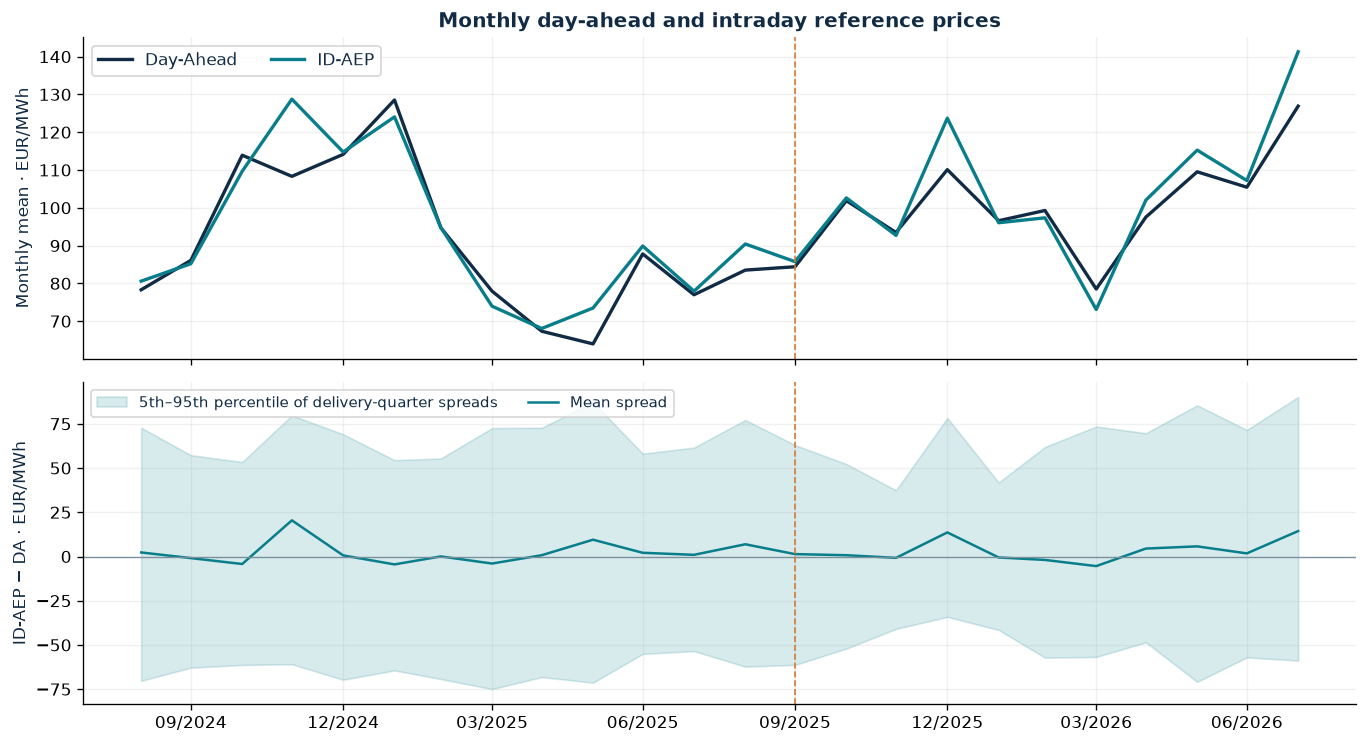

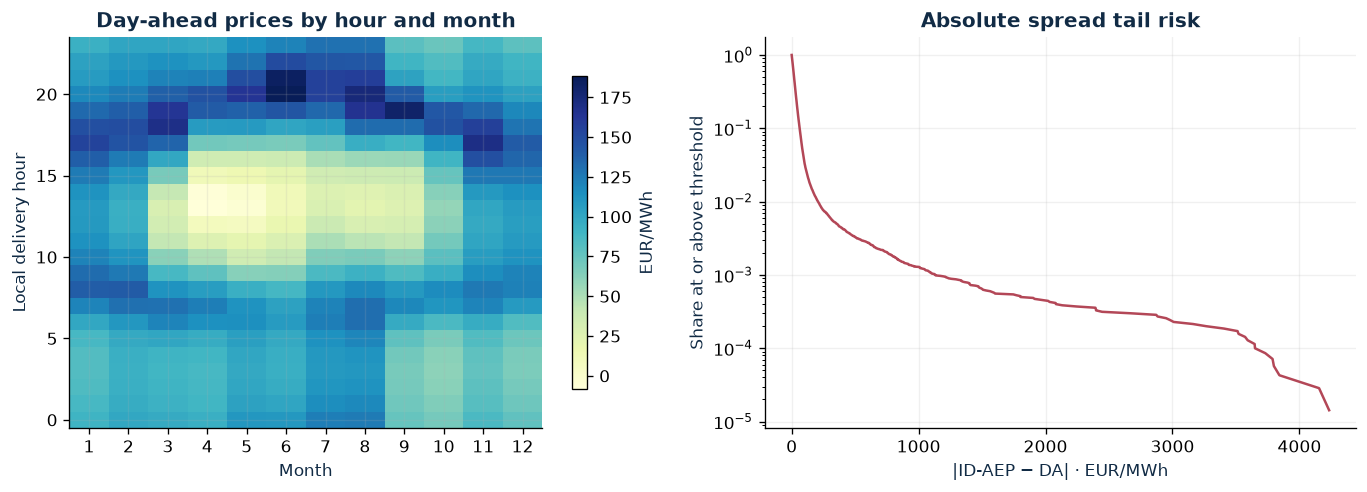

In [10]:
monthly=d[['da_eur_mwh','id_aep_eur_mwh','spread']].tz_convert('Europe/Berlin').resample('MS').mean()
fig,axes=plt.subplots(2,1,figsize=(11.5,6.3),sharex=True)
axes[0].plot(monthly.index,monthly.da_eur_mwh,label='Day-Ahead',color=COLORS['navy'],lw=2)
axes[0].plot(monthly.index,monthly.id_aep_eur_mwh,label='ID-AEP',color=COLORS['teal'],lw=2)
axes[0].set(title='Monthly day-ahead and intraday reference prices',ylabel='Monthly mean · EUR/MWh');axes[0].legend(ncol=2)
q=d.spread.tz_convert('Europe/Berlin').resample('MS').quantile([.05,.95]).unstack()
axes[1].fill_between(q.index,q[.05],q[.95],color=COLORS['teal'],alpha=.16,label='5th–95th percentile of delivery-quarter spreads')
axes[1].plot(monthly.index,monthly.spread,color=COLORS['teal'],label='Mean spread')
axes[1].axhline(0,color=COLORS['grey'],lw=.8)
for ax in axes:ax.axvline(pd.Timestamp('2025-10-01',tz='UTC'),color=COLORS['orange'],ls='--',lw=1)
axes[1].set(ylabel='ID-AEP − DA · EUR/MWh');axes[1].legend(ncol=2,fontsize=9)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%m/%Y'))
save_chart(fig,'01_market_regimes')

fig,axes=plt.subplots(1,2,figsize=(11.5,4.2))
heat=d.pivot_table(index='hour',columns='month',values='da_eur_mwh',aggfunc='mean')
im=axes[0].imshow(heat,aspect='auto',origin='lower',cmap='YlGnBu')
axes[0].set(title='Day-ahead prices by hour and month',xlabel='Month',ylabel='Local delivery hour')
axes[0].set_xticks(range(12),range(1,13));fig.colorbar(im,ax=axes[0],label='EUR/MWh',shrink=.8)
tail=d.spread.abs().sort_values().to_numpy();survival=(len(tail)-np.arange(len(tail)))/len(tail)
axes[1].semilogy(tail,survival,color=COLORS['red'])
axes[1].set(xlabel='|ID-AEP − DA| · EUR/MWh',ylabel='Share at or above threshold',title='Absolute spread tail risk')
save_chart(fig,'02_patterns_and_tails')

## 3 · Fundamentals: explaining a spread is different from predicting it

Residual-load forecast error is calculated as:

`(actual load − actual wind − actual solar) − (forecast load − forecast wind − forecast solar)`.

A positive value means more residual demand than forecast. It is not the NRV balance, an individual trader's imbalance or a measure of balancing-energy demand.

The left chart groups observations into ten forecast-error bins and plots mean and median spreads. The right chart shows the density of DA prices against realised residual load. These are historical relationships. Realised errors are known after the event and are excluded from the forecasting features.

A tradable forecast-revision signal would require timestamped vintages with `issued_at`, `received_at` and `valid_for`. Retrospectively revised fundamentals are used here only for explanation.


,error_gw,spread_mean,spread_median,n
error_bin,,,,
"(-14.213999999999999, -4.211]",-6.14,-14.00,-13.36,7008
"(-4.211, -2.642]",-3.34,-9.84,-10.10,7008
"(-2.642, -1.656]",-2.13,-7.61,-7.54,7008
"(-1.656, -0.815]",-1.22,-3.52,-5.62,7008
"(-0.815, -0.0387]",-0.43,-1.33,-4.69,7008
"(-0.0387, 0.791]",0.36,1.92,-1.98,7009
"(0.791, 1.753]",1.26,3.98,-0.11,7007
"(1.753, 2.86]",2.29,6.91,1.26,7009
"(2.86, 4.561]",3.61,18.38,4.64,7007


spread               1.00
residual_error_gw    0.26
residual_load_mw    -0.05
net_import_mw       -0.06
gas_generation_mw   -0.02
Name: Spearman with spread (ex post), dtype: float64

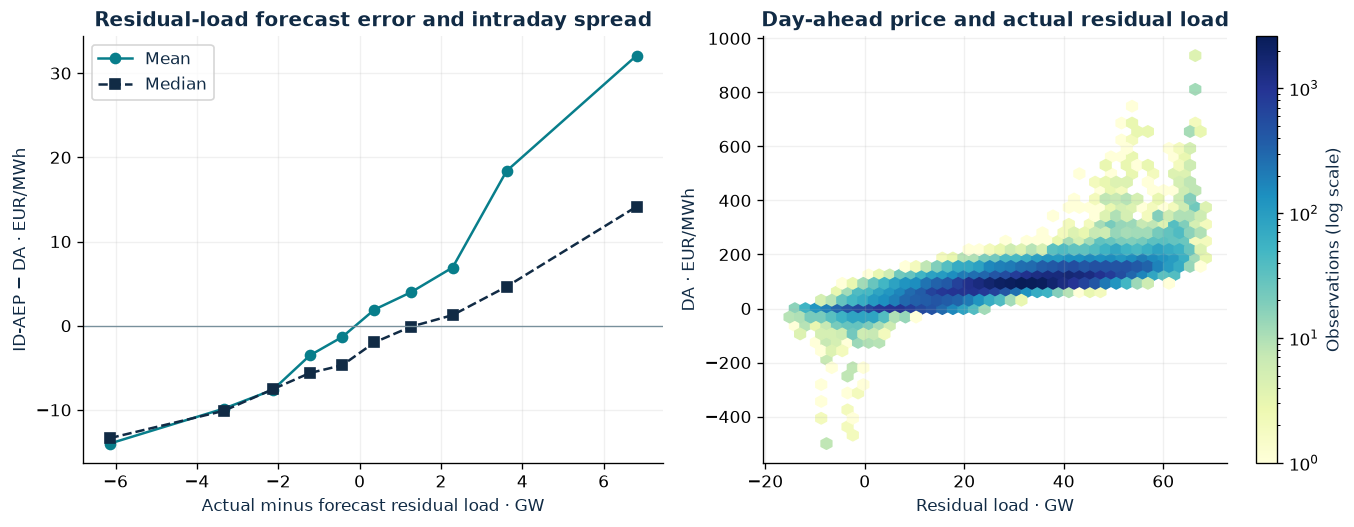

In [11]:
fund=d[['residual_error_gw','spread','residual_load_mw','da_eur_mwh','net_import_mw','gas_generation_mw','local_day']].dropna().copy()
fund['error_bin']=pd.qcut(fund.residual_error_gw,10,duplicates='drop')
bins=fund.groupby('error_bin',observed=True).agg(error_gw=('residual_error_gw','mean'),spread_mean=('spread','mean'),spread_median=('spread','median'),n=('spread','size'))
correlation=fund[['spread','residual_error_gw','residual_load_mw','net_import_mw','gas_generation_mw']].corr(method='spearman')['spread']
display(bins);display(correlation.rename('Spearman with spread (ex post)'))
fig,axes=plt.subplots(1,2,figsize=(11.5,4.5))
axes[0].plot(bins.error_gw,bins.spread_mean,'o-',color=COLORS['teal'],label='Mean')
axes[0].plot(bins.error_gw,bins.spread_median,'s--',color=COLORS['navy'],label='Median')
axes[0].axhline(0,color=COLORS['grey'],lw=.8)
axes[0].set(title='Residual-load forecast error and intraday spread',xlabel='Actual minus forecast residual load · GW',ylabel='ID-AEP − DA · EUR/MWh');axes[0].legend()
hb=axes[1].hexbin(fund.residual_load_mw/1000,fund.da_eur_mwh,gridsize=40,bins='log',mincnt=1,cmap='YlGnBu')
axes[1].set(title='Day-ahead price and actual residual load',xlabel='Residual load · GW',ylabel='DA · EUR/MWh')
fig.colorbar(hb,ax=axes[1],label='Observations (log scale)')
save_chart(fig,'03_fundamental_drivers')

## 4 · Market-structure change: quarter-hour spread patterns

Before October 2025, four delivery quarters shared one hourly DA reference price, while intraday quarter-hour products were already traded. After the change, the DA auction also priced individual quarters. A pattern learned under the earlier structure may therefore fail in the later regime.

The first panel compares median spreads by local delivery quarter. The second compares October–August in successive years, giving each calendar month equal weight. Matching months reduces a simple seasonal mismatch, but weather, generation and other conditions also changed. The comparison does not isolate the effect of the pricing reform.


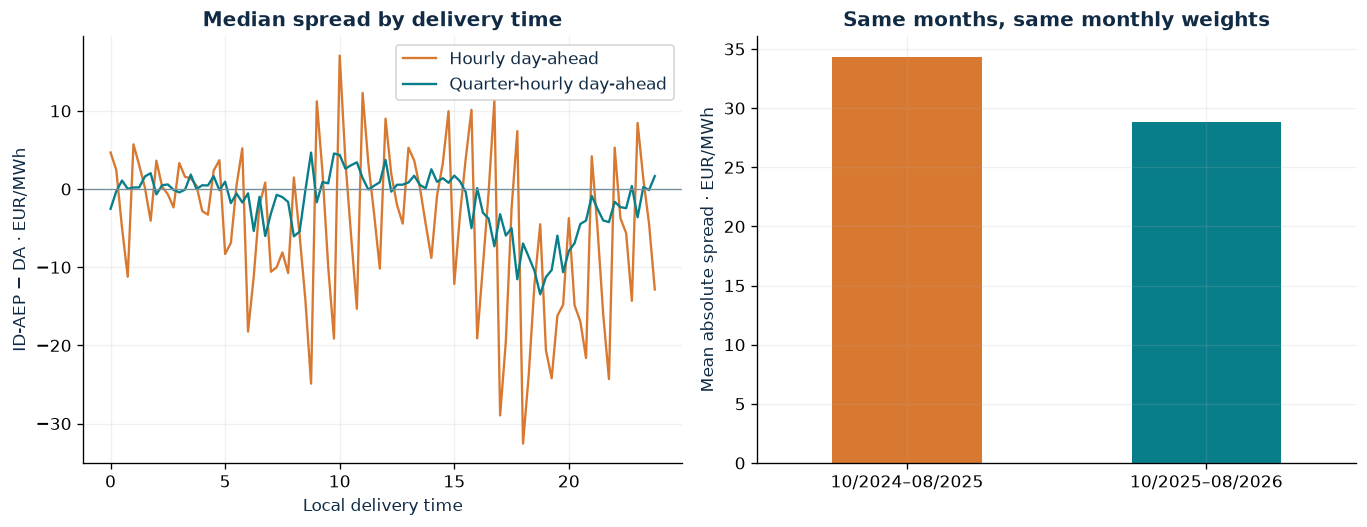

,median,Mean |spread| EUR/MWh,Share |spread| >100 (%)
period,,,
10/2024–08/2025,-3.75,34.36,3.51
10/2025–08/2026,-0.99,28.85,3.11


In [13]:
profile=d.groupby(['post_15m','hour','quarter']).spread.median().unstack(0)
fig,axes=plt.subplots(1,2,figsize=(11.5,4.5))
for regime,label,color in [(0,'Hourly day-ahead',COLORS['orange']),(1,'Quarter-hourly day-ahead',COLORS['teal'])]:
    v=profile[regime]
    x=np.array([h+q/4 for h,q in v.index])
    axes[0].plot(x,v.values,label=label,color=color,lw=1.4)
axes[0].axhline(0,color=COLORS['grey'],lw=.8);axes[0].set(title='Median spread by delivery time',xlabel='Local delivery time',ylabel='ID-AEP − DA · EUR/MWh');axes[0].legend()
# Hold the set of calendar months constant and give each month equal weight.
matched=d[d.month!=9].copy()
matched['period']=np.where(matched.post_15m.eq(0),'10/2024–08/2025','10/2025–08/2026')
matched_stats=matched.groupby(['period','month']).spread.agg(median='median',mae=lambda x:x.abs().mean(),tail=lambda x:(x.abs()>100).mean()*100).groupby('period').mean()
matched_stats['mae'].plot.bar(ax=axes[1],color=[COLORS['orange'],COLORS['teal']],rot=0)
axes[1].set(title='Same months, same monthly weights',ylabel='Mean absolute spread · EUR/MWh',xlabel='')
save_chart(fig,'04_quarter_hour_regime')
display(matched_stats.rename(columns={'mae':'Mean |spread| EUR/MWh','tail':'Share |spread| >100 (%)'}))

## 5 · Forecast design and chronological validation

**Target:** the later spread `ID-AEP − DA`. The gradient-boosting model uses absolute-error loss, which estimates a conditional median rather than an expected profit. The assumed decision time is **18:00 local time on D−1**, after the DA price curve is published. Features contain that curve and calendar information; realised fundamentals and future ID prices are excluded.

The separate battery exercise uses a **10:00 D−1** price forecast built from calendar features and DA prices lagged by at least 48 hours. The target day's DA auction price is not an input to that forecast.

| Item | Specification |
|---|---|
| Test period | September 2025–August 2026; twelve consecutive monthly windows |
| Training | Up to 365 days before calibration; shorter for early windows |
| Calibration | 60 days after training, before the test |
| Gap | Seven days between calibration and the test month |
| Benchmarks | Zero spread, historical delivery-time median and Ridge regression |
| ML model | Histogram Gradient Boosting with fixed parameters |
| Prediction interval | Target 80% coverage, calibrated from absolute forecast errors |
| Evaluation | MAE, RMSE, bias, monthly stability, stress coverage and seven-day block bootstrap |

Each test month remains outside fitting and calibration. The seven-day gap is a conservative data-availability assumption, not proof of historical publication timing. Public series may be revised, so chronological separation does not replace a complete as-of dataset. Time dependence and changing market conditions can also reduce interval coverage.

The work is exploratory, not a preregistered study. Model parameters are not changed in response to individual test-month results.


In [14]:
def new_model():
    # Parameters fixed before examining evaluation results; no test-set search.
    return HistGradientBoostingRegressor(
        loss="absolute_error", max_iter=120, max_leaf_nodes=15,
        min_samples_leaf=120, learning_rate=0.06, l2_regularization=10,
        early_stopping=False, random_state=42,
    )


def walk_forward(d):
    """Monthly expanding evaluation; trailing training, calibration, then embargo.

    ID: D-1 18:00, known DA delivery-day curve + calendar only.
    DA: D-1 10:00, old DA prices + calendar only.
    Label revision vintages are unavailable; this is not a certified as-of replay.
    """
    predictions, audits = [], []
    starts = pd.date_range("2025-09-01", "2026-08-01", freq="MS", tz="Europe/Berlin")
    for start_local in starts:
        start = start_local.tz_convert("UTC")
        end = (start_local + pd.offsets.MonthBegin(1)).tz_convert("UTC")
        calibration_end = start - pd.Timedelta(days=7)
        calibration_start = calibration_end - pd.Timedelta(days=60)
        train_start = calibration_start - pd.Timedelta(days=365)
        train = d.loc[(d.index >= train_start) & (d.index < calibration_start)].dropna(subset=ID_FEATURES+["spread"])
        cal = d.loc[(d.index >= calibration_start) & (d.index < calibration_end)].dropna(subset=ID_FEATURES+["spread"])
        test = d.loc[(d.index >= start) & (d.index < end)].copy()
        assert len(train) > 1000 and len(cal) > 1000
        assert train.index.max() < cal.index.min() < cal.index.max() < test.index.min()
        model = new_model().fit(train[ID_FEATURES], train["spread"])
        eligible = test[ID_FEATURES].notna().all(axis=1)
        test["pred_hgb"] = np.nan
        test.loc[eligible, "pred_hgb"] = model.predict(test.loc[eligible, ID_FEATURES])
        seasonal = train.groupby(["hour", "quarter"])["spread"].median()
        keys = pd.MultiIndex.from_frame(test[["hour", "quarter"]])
        test["pred_seasonal"] = seasonal.reindex(keys).to_numpy()
        test["pred_zero"] = 0.0
        ridge = make_pipeline(StandardScaler(), Ridge(alpha=100.0)).fit(train[ID_FEATURES],train["spread"])
        test["pred_ridge"] = np.nan
        test.loc[eligible,"pred_ridge"] = ridge.predict(test.loc[eligible,ID_FEATURES])
        residuals = np.abs(cal["spread"].to_numpy() - model.predict(cal[ID_FEATURES]))
        # Split-calibration score; serial dependence means coverage is empirical.
        q = np.quantile(residuals, min(1.0, np.ceil((len(residuals)+1)*0.8)/len(residuals)), method="higher")
        test["lower_spread"] = test["pred_hgb"] - q
        test["upper_spread"] = test["pred_hgb"] + q
        test["fold"] = start_local.strftime("%Y-%m")
        # Separate pre-auction model. No same-day DA or revised fundamentals.
        da_train = d.loc[(d.index >= start-pd.Timedelta(days=365)) & (d.index < calibration_end)].dropna(subset=DA_FEATURES+["da_eur_mwh"])
        da_model = new_model().fit(da_train[DA_FEATURES], da_train["da_eur_mwh"])
        ok = test[DA_FEATURES].notna().all(axis=1)
        test["da_prediction"] = np.nan
        test.loc[ok, "da_prediction"] = da_model.predict(test.loc[ok, DA_FEATURES])
        test["da_baseline"] = 0.5*test["da_lag_48h"] + 0.5*test["da_lag_168h"]
        predictions.append(test)
        audits.append({"fold":start_local.strftime("%Y-%m"),"train_n":len(train),"cal_n":len(cal),
                       "test_n":len(test),"train_last_utc":str(train.index.max()),
                       "cal_last_utc":str(cal.index.max()),"test_first_utc":str(test.index.min()),
                       "band_halfwidth_eur_mwh":q})
        print(f"{start_local:%Y-%m}: train={len(train):,}, cal={len(cal):,}, test={len(test):,}")
    return pd.concat(predictions), pd.DataFrame(audits)


def forecast_metrics(oos):
    rows=[]
    common=oos.dropna(subset=["spread","pred_zero","pred_seasonal","pred_ridge","pred_hgb"])
    for col in ["pred_zero","pred_seasonal","pred_ridge","pred_hgb"]:
        error=common[col]-common["spread"]
        # Zero forecasts have no directional call; don't award them a hit rate.
        active=common[col].abs()>1e-9
        rows.append({"model":col,"n":len(common),"MAE":error.abs().mean(),
                     "RMSE":np.sqrt((error**2).mean()),"bias":error.mean(),
                     "direction_pct":100*(np.sign(common.loc[active,col])==np.sign(common.loc[active,'spread'])).mean() if active.any() else np.nan})
    return pd.DataFrame(rows).set_index("model")


def block_bootstrap_mean(values, block_length=7, repetitions=2000, seed=42):
    """Moving-block bootstrap of daily observations; CI, not a profit guarantee."""
    a=np.asarray(values,dtype=float);a=a[np.isfinite(a)]
    rng=np.random.default_rng(seed);n=len(a)
    assert n >= block_length
    starts=rng.integers(0,n-block_length+1,size=(repetitions,int(np.ceil(n/block_length))))
    indexes=(starts[:,:,None]+np.arange(block_length)).reshape(repetitions,-1)[:,:n]
    means=a[indexes].mean(axis=1)
    return tuple(np.quantile(means,[.025,.975]))

In [15]:
oos,audit=walk_forward(d)
metrics=forecast_metrics(oos)
display(metrics)
display(audit[['fold','train_n','cal_n','test_n','band_halfwidth_eur_mwh']])
audit.to_csv(REPORTS/'validation_audit.csv',index=False)
metrics.to_csv(REPORTS/'intraday_metrics.csv')
common=oos.dropna(subset=['spread','pred_zero','pred_seasonal','pred_ridge','pred_hgb'])
errors=pd.DataFrame({c:(common[c]-common.spread).abs() for c in ['pred_zero','pred_seasonal','pred_ridge','pred_hgb']},index=common.index)
monthly_mae=errors.groupby(common.fold).mean()
monthly_mae.to_csv(REPORTS/'monthly_mae.csv')
daily_improvement=(errors.pred_zero-errors.pred_hgb).groupby(common.local_day).mean()
improvement_ci=block_bootstrap_mean(daily_improvement)
coverage=(common.spread.between(common.lower_spread,common.upper_spread))
stress=common.spread.abs()>100
print(f"Mean daily MAE improvement over zero spread: {daily_improvement.mean():.2f} EUR/MWh; 95% block CI [{improvement_ci[0]:.2f}, {improvement_ci[1]:.2f}]")
print(f"80% band coverage: {100*coverage.mean():.1f}%; coverage when |spread| >100: {100*coverage[stress].mean():.1f}% (n={stress.sum()})")
print(f"Direction-neutral benchmark: majority spread sign in the test sample = {100*max((common.spread>0).mean(),(common.spread<0).mean()):.1f}% (descriptive only)")

2025-09: train=28,608, cal=5,760, test=2,880
2025-10: train=31,488, cal=5,760, test=2,980
2025-11: train=34,468, cal=5,760, test=2,880
2025-12: train=35,040, cal=5,760, test=2,976
2026-01: train=35,040, cal=5,760, test=2,976
2026-02: train=35,040, cal=5,760, test=2,688
2026-03: train=35,040, cal=5,760, test=2,972
2026-04: train=35,040, cal=5,760, test=2,880
2026-05: train=35,040, cal=5,760, test=2,976
2026-06: train=35,040, cal=5,760, test=2,880
2026-07: train=35,040, cal=5,760, test=2,976
2026-08: train=35,040, cal=5,760, test=2,976


,n,MAE,RMSE,bias,direction_pct
model,,,,,
pred_zero,35040,29.56,80.47,-3.41,NaN
pred_seasonal,35040,30.17,81.00,-7.25,51.87
pred_ridge,35040,30.77,80.87,-2.81,51.57
pred_hgb,35040,29.65,82.31,-10.57,55.16


,fold,train_n,cal_n,test_n,band_halfwidth_eur_mwh
0,2025-09,28608,5760,2880,36.52
1,2025-10,31488,5760,2980,35.60
2,2025-11,34468,5760,2880,39.51
3,2025-12,35040,5760,2976,36.56
4,2026-01,35040,5760,2976,31.71
5,2026-02,35040,5760,2688,31.00
6,2026-03,35040,5760,2972,32.49
7,2026-04,35040,5760,2880,33.88
8,2026-05,35040,5760,2976,39.80
9,2026-06,35040,5760,2880,39.18


Mean daily MAE improvement over zero spread: -0.09 EUR/MWh; 95% block CI [-0.69, 0.53]
80% band coverage: 77.8%; coverage when |spread| >100: 5.8% (n=1142)
Direction-neutral benchmark: majority spread sign in the test sample = 52.0% (descriptive only)


## 6 · Forecast results: benchmarks, stability and stress events

All models are evaluated on the same delivery quarters. Lower MAE means smaller average absolute forecast errors; it does not establish trading revenue. The monthly chart shows whether relative performance is consistent or concentrated in particular periods.

The coverage panel compares the interval's empirical coverage with its 80% target. Stress coverage is assessed separately for realised absolute spreads above EUR 100/MWh; this selection is used only for evaluation. The final chart deliberately shows the day containing the largest absolute test spread, so that a difficult case remains visible.


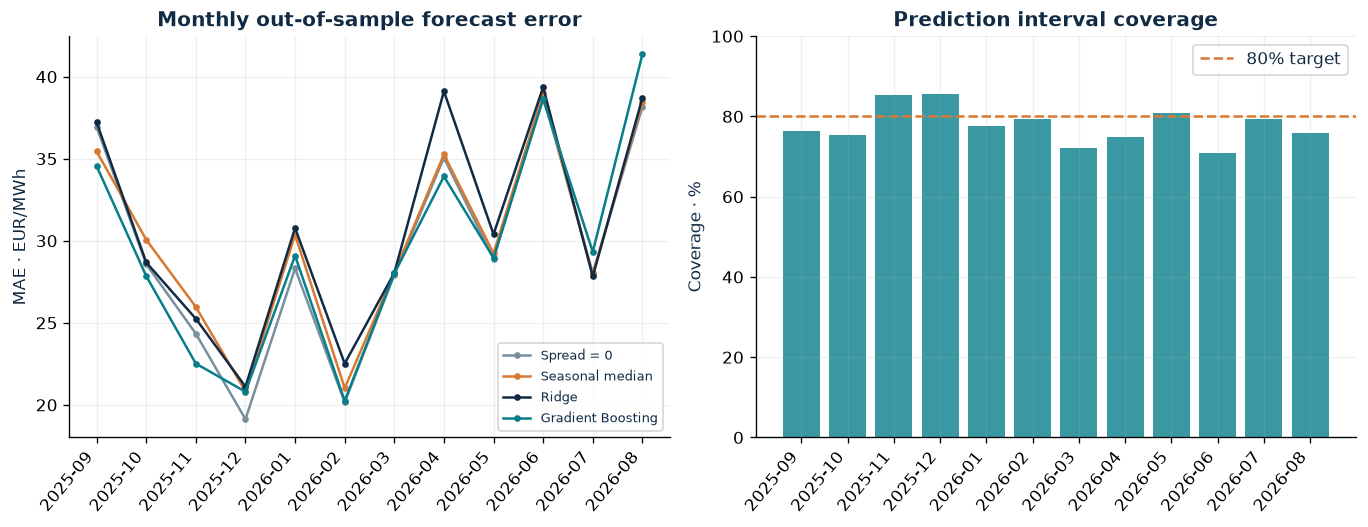

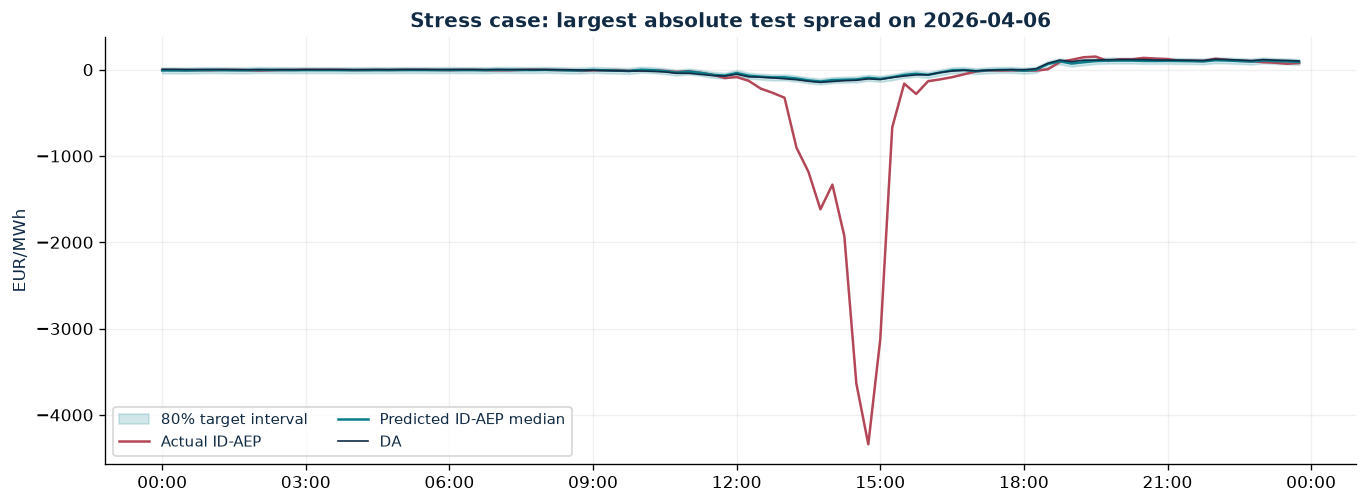

In [16]:
fig,axes=plt.subplots(1,2,figsize=(11.5,4.5))
for col,label,color in [('pred_zero','Spread = 0',COLORS['grey']),('pred_seasonal','Seasonal median',COLORS['orange']),('pred_ridge','Ridge',COLORS['navy']),('pred_hgb','Gradient Boosting',COLORS['teal'])]:
    axes[0].plot(range(len(monthly_mae)),monthly_mae[col],marker='o',ms=3,label=label,color=color)
axes[0].set_xticks(range(len(monthly_mae)),monthly_mae.index,rotation=50,ha='right')
axes[0].set(title='Monthly out-of-sample forecast error',ylabel='MAE · EUR/MWh');axes[0].legend(fontsize=8)
cover_month=coverage.groupby(common.fold).mean()*100
axes[1].bar(range(len(cover_month)),cover_month,color=COLORS['teal'],alpha=.8)
axes[1].axhline(80,color=COLORS['orange'],ls='--',label='80% target')
axes[1].set_xticks(range(len(cover_month)),cover_month.index,rotation=50,ha='right')
axes[1].set(title='Prediction interval coverage',ylabel='Coverage · %',ylim=(0,100));axes[1].legend()
save_chart(fig,'05_walk_forward_validation')

# Deterministic stress case: largest |spread| day in the OOS set, not a success showcase.
stress_day=common.loc[common.spread.abs().idxmax(),'local_day']
event=common[common.local_day==stress_day]
fig,ax=plt.subplots(figsize=(11.5,4.3))
x=event.index.tz_convert('Europe/Berlin')
ax.fill_between(x,event.da_eur_mwh+event.lower_spread,event.da_eur_mwh+event.upper_spread,color=COLORS['teal'],alpha=.18,label='80% target interval')
ax.plot(x,event.id_aep_eur_mwh,color=COLORS['red'],label='Actual ID-AEP')
ax.plot(x,event.da_eur_mwh+event.pred_hgb,color=COLORS['teal'],label='Predicted ID-AEP median')
ax.plot(x,event.da_eur_mwh,color=COLORS['navy'],lw=1,label='DA')
ax.set(title=f'Stress case: largest absolute test spread on {stress_day}',ylabel='EUR/MWh')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M',tz=x.tz));ax.legend(ncol=2,fontsize=9)
save_chart(fig,'06_stress_case')

## Main findings

The forecasting models did not consistently outperform the zero-spread benchmark across the twelve test months. Prediction-interval coverage also varied and was often below the 80% target.

The extreme event on 6 April 2026 highlights a limitation: the model missed a sharp negative intraday price movement, which fell well outside its prediction interval. These results suggest that the current approach needs better information about changing market conditions before it could support trading decisions.

## Sources and methodology references

- **[S1] Fraunhofer ISE, Energy-Charts API:** https://api.energy-charts.info/ ; API schema: https://api.energy-charts.info/openapi.json . Endpoints: `price`, `public_power`, `public_power_forecast`, `cbpf`. Original snapshot retrieval: 28 September 2026. Attribute DA prices to Bundesnetzagentur / SMARD and the other used series to energy-charts.info under CC BY 4.0.
- **[S2] German transmission system operators, ID-AEP definition and CSV:** https://www.netztransparenz.de/de-de/Regelenergie/Ausgleichsenergiepreis/Index-Ausgleichsenergiepreis . Usage information: https://www.netztransparenz.de/de-de/Impressum . Raw index data are downloaded by the user; no open redistribution licence is assumed.
- **[S3] EPEX SPOT, 15-minute products in market coupling:** https://www.epexspot.com/en/15-minute-products-market-coupling . Delivery-date transition used in this study: 1 October 2025.
- **[S4] SMARD forecast data:** https://www.smard.de/page/en/wiki-article/5884/206318 . Downloads: https://www.smard.de/en/downloadcenter/download-market-data . Licence: https://creativecommons.org/licenses/by/4.0/ .
- **[S5] Forecasting methods — scikit-learn:** [Histogram Gradient Boosting](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.HistGradientBoostingRegressor.html), [Ridge regression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html) and [StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html).